# Microcircuit example

## Step 1: Import the package

Import the microcircuit python package and the default parameters:

In [1]:
from microcircuit import network
from microcircuit.network_params import default_net_dict as net_dict
from microcircuit.sim_params import default_sim_dict as sim_dict
from microcircuit.stimulus_params import default_stim_dict as stim_dict


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Dec 10 2025 08:34:56

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## Step 2: Configure the network and the simulation environment.

Overwrite the default scaling factor to reduce the network size. The parameters `N_scaling` and `K_scaling` scale the total number of neurons and the total number of synapses, respectively.

In [2]:
scaling_factor = 0.2
net_dict["N_scaling"] = scaling_factor
net_dict["K_scaling"] = scaling_factor

Set the simulation time (in ms) and the path to the simulation data. Suppress printing the simulation progress to screen.

In [3]:
sim_dict['sim_time'] = 200.
sim_dict['data_path'] = 'data/'
sim_dict['print_time'] = False

## Step 3: Create the network

Instantiate the network. At this point, the primary parameters stored in `sim_dict`, `net_dict`, and `stim_dict` are attached to the network instance, and all secondary parameters are computed.

In [4]:
net = network.Network(sim_dict, net_dict, stim_dict)

Data will be written to: data/
  Directory already existed. Old data will be overwritten.

Neuron numbers are scaled by a factor of 0.200.
Indegrees are scaled by a factor of 0.200.
  Weights and DC input are adjusted to compensate.

RNG seed: 55
Total number of virtual processes: 4

Mar 03 11:13:26 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


/home/tetzlaff/work/projects/microcircuit/microcircuit-PD14-model/PyNEST/src/microcircuit/network.py:283: UserWarning:
Population L23E is sub-threshold with downscaled DC input amplitude and may not fire. 
/home/tetzlaff/work/projects/microcircuit/microcircuit-PD14-model/PyNEST/src/microcircuit/network.py:283: UserWarning:
Population L23I is sub-threshold with downscaled DC input amplitude and may not fire. 


Here, the `UserWarning`s inform you that with the scaling factor of 0.2, two of the eight populations (L23E, L23I) receive too little (cortico-cortical) background inputs to fire in isolation. They may still generate spikes due to local inputs from other neurons within the network.

Create all neurons and devices, and connect the network.

In [5]:
net.create()
net.connect()

Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
Connecting neuronal populations recurrently.

Mar 03 11:13:28 NodeManager::prepare_nodes [Info]: 
    Preparing 15467 nodes for simulation.


## Step 4: Run the simulation

Simulate the network for `sim_dict['sim_time']` ms.

In [6]:
net.simulate(net.sim_dict['sim_time'])

Simulating 200.0 ms.

Mar 03 11:13:28 NodeManager::prepare_nodes [Info]: 
    Preparing 15467 nodes for simulation.

Mar 03 11:13:28 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 15467
    Simulation time (ms): 200
    Number of OpenMP threads: 4
    Not using MPI

Mar 03 11:13:31 SimulationManager::run [Info]: 
    Simulation finished.


## Step 5: Inspect the recorded spiking activity

The recorded spike data can be loaded from disk and visualized using the function `helpers.plot_raster()`. 

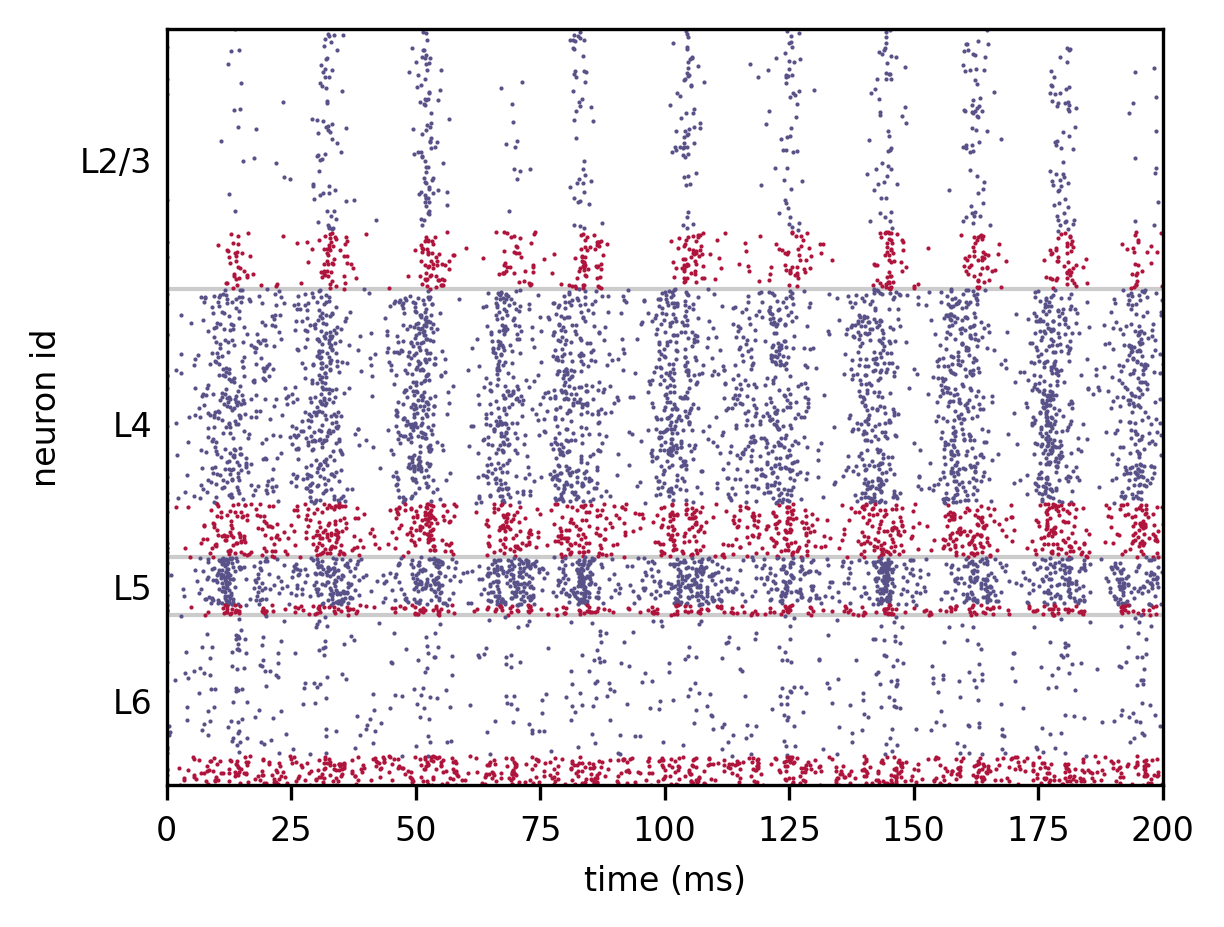

In [7]:
import  microcircuit.helpers as helpers
helpers.plot_raster(
    path = net.sim_dict['data_path'], 
    name = "spike_recorder", 
    begin = 0, 
    end = net.sim_dict['sim_time'], 
    N_scaling = 0 #scaling_factor
)

Visualization of the spiking activity in the network. Each dot represents a spike of the respective neuron at a given point in time.  Neuron ID's are sorted according to subpopulations (layers). Blue and red dots refer to spikes from excitatory and inhibitory neurons, respectively.